In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
from tqdm import tqdm

In [2]:
two_dim = False
inputname = 'runs/22_8/H_input_2025-08-22_12-11-13.txt'
outputname = 'runs/22_8/H_output_2025-08-22_12-11-13.txt'
orbit_plot = True
input_plot = False #if True plots the initial distribution from the input

In [3]:
def input_opening(inputname = ''):
    inputf = open(inputname, 'r')

    N = int(inputf.readline())
    n_dim = int(inputf.readline())
        
    t_0 = float(inputf.readline())

    mass_0 = []
    for i in range(3, N+3):
        mass_0.append(float(inputf.readline()))
        
    mass_0 = np.array(mass_0)
    
    #the initial positions are arranged in an array where the first index gives the particle 
    #and the second gives the direction
    position_0 = []
    for i in range(N+4, 2*N + 4):
        position_0.append((inputf.readline()).rstrip())
        
    position_0 = [p.split() for p in position_0]

    for i in range(N):
        for j in range(n_dim):
            position_0[i][j] = float(position_0[i][j])
            
    position_0 = np.array(position_0)

    #the initial velocities are arranged just like the positions
    velocity_0 = []
    for i in range(2*N + 5, 3*N + 5):
        velocity_0.append((inputf.readline()).rstrip())
        
    velocity_0 = [v.split() for v in velocity_0]

    for i in range(N):
        for j in range(n_dim):
            velocity_0[i][j] = float(velocity_0[i][j])
            
    velocity_0 = np.array(velocity_0)
    inputf.close() 
    
    return N, t_0, mass_0, position_0, velocity_0

def output_opening(outputname = ''):
    outputf = open(outputname, 'r')
    output = outputf.readlines() #reading all the lines as one compact object
    outputf.close()

    output = [o.split() for o in output]  #splitting them in each line
    #output is a list of each line, where each line is a list itself

    N = int(output[0][0]) #taking the first element as the # of particles
    output_l = len(output) #checking the length of the file
    #print(output_l)
    snapshot_n = int(output_l/(3 + 3*N)) #and dividing by 3*N + 3 to get the # of snapshots
    
    time = np.empty(snapshot_n)
    time = [float(output[i][0]) for i in range(2, output_l, 3*N + 3)]
    
    position = np.empty([N, snapshot_n, 3]) #position of i particle at s snapshot 
    velocity = np.empty([N, snapshot_n, 3]) #same as position
    
    for i in range(N):
        for j, k in zip(range(snapshot_n), range(3 + N + i, output_l, 3*N + 3)):
            position[i][j] = output[k]
    
    for i in range(N):
        for j, k in zip(range(snapshot_n), range(3 + 2*N + i, output_l, 3*N + 3)):
            velocity[i][j] = output[k]
    
    return N, snapshot_n, time, position, velocity

In [4]:
n_particles, init_t, mass, init_p, init_v = input_opening(inputname)

if input_plot:
    fig = plt.figure()
    if (two_dim == True):
        ax = fig.add_subplot()
        for i in range(n_particles): ax.scatter(init_p[i][0], init_p[i][1], color = 'b')
        ax.set(xlabel = 'x', ylabel = 'y', title = str(n_particles) + ' particles')
    else:
        ax = fig.add_subplot(projection='3d')
        for i in range(n_particles): ax.scatter(init_p[i][0], init_p[i][1], init_p[i][2], color = 'b', s = 1)
        ax.set(xlabel = 'x', ylabel = 'y', zlabel = 'z', title = str(n_particles) + ' particles')

    plt.show()

In [5]:
N, snap_number, time, positions, velocities = output_opening(outputname)

In [6]:
radius = []
for i in range(n_particles): radius.append(np.sqrt(positions[i, :, 0]**2 + positions[i, :, 1]**2 + positions[i, :, 2]**2))
radius = np.array(radius)

radius_at_t = []
for i in range(len(time)): radius_at_t.append(np.sqrt(positions[:, i, 0]**2 + positions[:, i, 1]**2 + positions[:, i, 2]**2))
radius_at_t = np.array(radius_at_t)

Text(0.5, 0, 'time')

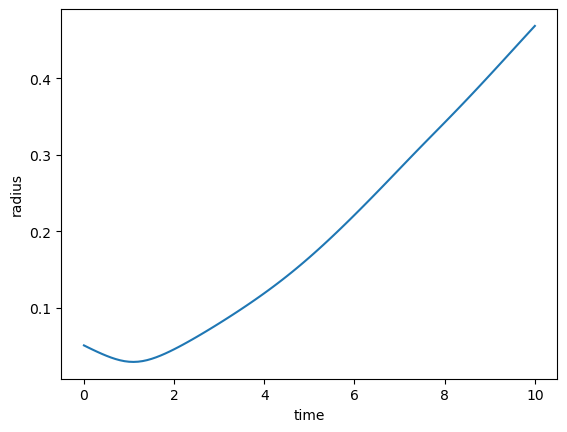

In [7]:
plt.plot(time, radius[0])
plt.ylabel('radius')
plt.xlabel('time')

Text(0.5, 0, 'time')

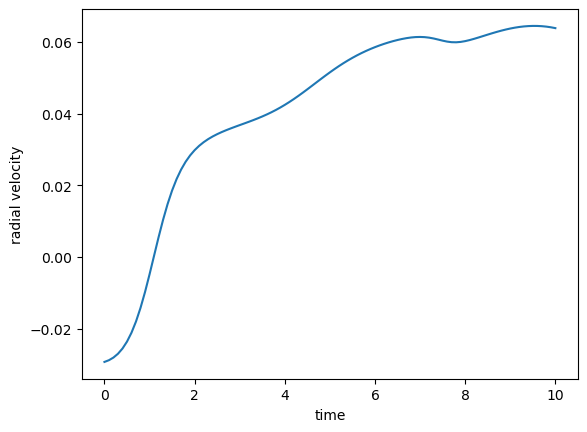

In [8]:
radial_v = []
for i in range(n_particles): radial_v.append((positions[i, :, 0]*velocities[i, :, 0] + positions[i, :, 1]*velocities[i, :, 1] + positions[i, :, 2]*velocities[i, :, 2])/radius[i, :])
radial_v = np.array(radial_v)

plt.plot(time, radial_v[0])
plt.ylabel('radial velocity')
plt.xlabel('time')

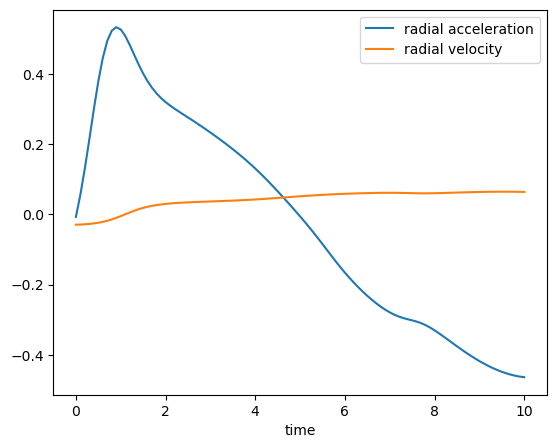

In [9]:
r_acc = np.gradient(radial_v)/np.gradient(time)

fig = plt.figure(figsize = (14, 5))

ax = fig.add_subplot(121)
ax.plot(time, r_acc[0, 0], label = 'radial acceleration')
ax.plot(time, radial_v[0], label = 'radial velocity')
ax.set(xlabel = 'time')
plt.legend()

In [10]:
gifname=outputname.replace('output_', '')
gifname=gifname.replace('txt', 'gif')
print(gifname)

runs/22_8/H_2025-08-22_12-11-13.gif


MovieWriter ffmpeg unavailable; using Pillow instead.


starting animation


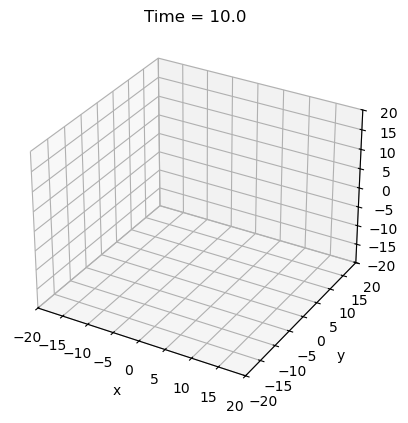

In [11]:
import matplotlib.animation as animation

fig = plt.figure()
ax = fig.add_subplot(projection='3d', computed_zorder=False)
ax.set_aspect('auto')
ax.set(xlim = [-20, 20], ylim = [-20, 20], zlim = [-20, 20], xlabel='x', ylabel='y', zlabel = 'z')

scatter_pert, = ax.plot([], [], [], 'o', markersize = '3', color = 'red', zorder = 1)
scatters, = ax.plot([], [], [], 'o', color='cornflowerblue', markersize = '1', alpha = 0.5, zorder=0)

print('starting animation')

def init():
    scatters.set_data([],[])
    scatters.set_3d_properties([])

    scatter_pert.set_data([],[])
    scatter_pert.set_3d_properties([])
    
    return scatters, scatter_pert
    
def update(frame):
    scatters.set_data(positions[:, frame, 0], positions[:, frame, 1]) 
    scatters.set_3d_properties(positions[:, frame, 2])
    
    #scatter_pert.set_data(positions[0, frame, 0], positions[0, frame, 1])
    #scatter_pert.set_3d_properties(positions[0, frame, 2])
    
    ax.set_title('Time = %.1f'%(time[frame]))

    return scatters, scatter_pert
    
ani = animation.FuncAnimation(fig, update, snap_number, interval=100, init_func = init)

ani.save(gifname, writer = 'ffmpeg')
#ani.save('Hernquist_try.mp4', writer = animation.FFMpegWriter())

In [12]:
#Get the total energies from the log file, in the CM frame
def GetEnergy(filename, N):
    file_output = open(filename, "r")
    output = np.array(file_output.read().splitlines())
    
    idx = np.where(output == output[9])[0] #Find the row with T and U

    E = []
    K = []
    U = []
    t = []
    
    for i in idx:
        t.append(float(output[i+1].split()[0]))
        E.append(float(output[i + 1].split()[1]))
        K.append(float(output[i + 1].split()[2]))
        U.append(-float(output[i + 1].split()[3]))
        
    #K = (np.array(K) - K_CM) * M_sun / v_iu_cgs**2
    #U = np.array(U) * G_p * 
    #E = np.add(K, U)

    file_output.close()
    return t, E, K, U

In [13]:
time, E, K, U = GetEnergy('runs/22_8/H_log_2025-08-22_12-11-13.txt', n_particles)

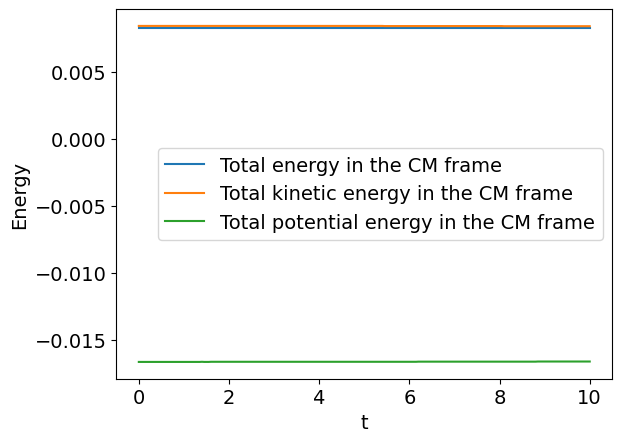

In [14]:
    #----------Plot of the energy----------

plt.plot(time, E, label="Total energy in the CM frame")
plt.plot(time, K, label="Total kinetic energy in the CM frame")
plt.plot(time, U, label="Total potential energy in the CM frame")
plt.xlabel("t", fontsize = 14)
plt.ylabel("Energy", fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

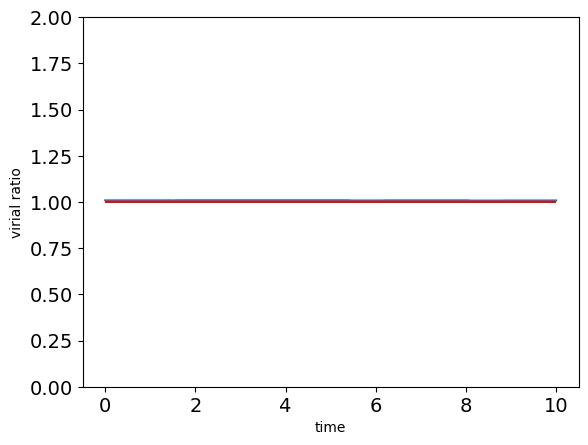

In [15]:
virial_ratio = []
for t in range(len(time)):
    virial_ratio.append(2 * K[t] / ( - U[t]))

plt.plot(time, virial_ratio)
plt.hlines(1.0, 0, max(time), color = 'r')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('time')
plt.ylabel('virial ratio')
plt.ylim(0, 2)
plt.show()

In [16]:
print(2 * K[0] / np.abs(U[0]))

1.0084033613445378


In [17]:
def compute_rho(radius):
    return M/(2*np.pi) * a/radius * 1/(radius+a)**3

M = 1
n = 5000
a = 1

In [18]:
def count_particles(radius, r_min, r_max):
    return int(np.sum((radius > r_min) & (radius < r_max)))

def numerical_density(radius, n_check):
    grid = np.geomspace(min(radius), max(radius), n_check)
    rho = []
    grid_centres = []
    
    for i in range(n_check-1):
        dn = count_particles(radius, grid[i], grid[i+1]) 
        if dn > 1:
            grid_centres.append(float(grid[i+1]))
            dV = 4*np.pi/3 * (grid[i+1]**3 - grid_centres[len(grid_centres)-2]**3)
            rho.append( (M/n) * (dn/dV) )
    
    return rho, grid_centres

/tmp/ipykernel_5608/2502167543.py:14: RuntimeWarning: divide by zero encountered in scalar divide 0/101 [00:00<?, ?it/s]
  rho.append( (M/n) * (dn/dV) )
  0%|                                                                                           | 0/101 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: 'density_pics/0.png'

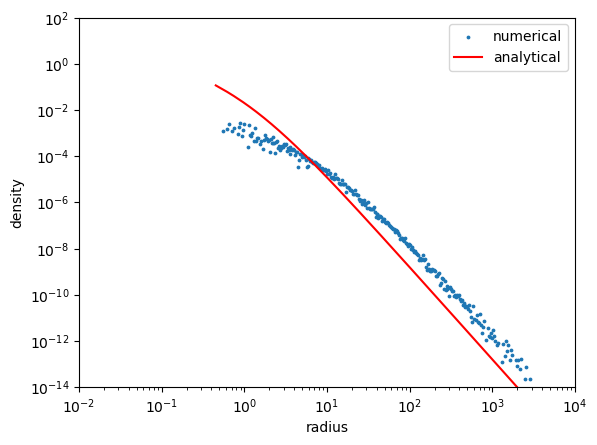

In [19]:
folder = 'density_pics/'
for i in tqdm(range(snap_number)):
    num_rho, rho_grid = numerical_density(radius_at_t[i], 500)

    analytical_rho = [compute_rho(rg) for rg in rho_grid]
    plt.scatter(rho_grid, num_rho, s = 3, label ='numerical')
    plt.plot(rho_grid, analytical_rho , c = 'r', label = 'analytical')
    plt.xlabel('radius')
    plt.ylabel('density')
    plt.xlim(1E-2, 1E4)
    plt.ylim(1E-14, 1E2)
    plt.legend()
    plt.loglog()
    plt.savefig(folder+str(i)+'.png', dpi=200)
    plt.close()

from moviepy import ImageSequenceClip

clip = ImageSequenceClip('./img_SF_LF/', fps = 7)
clip.write_videofile('movie_SF_LF.mp4')
clip.close()